# Whitening 비교 직접 실행

아래 **코드 셀 하나를 클릭하고 Shift + Enter**를 누르면 비교 분석을 다시 계산합니다. 약 1분 뒤 결과표와 그림 3개가 이 셀 아래에 나타납니다.

팀원의 기존 방법과 whitening을 추가한 방법을 같은 학습·시험 분할에서 평가합니다. 각 동작 30회씩 총 90회이며, 학습 81개·시험 9개로 번갈아 검사하는 10-fold 과정을 10회 반복합니다.

결과는 `results/whitening/`에 갱신됩니다. 분류 정확도 개선이 확인되더라도 한 사람의 한 기록에서 평가한 결과라는 점을 함께 해석합니다.

커널은 **Python 3 (ipykernel)**이며, 사용하는 Python은 `/Users/hhlee/miniconda3/envs/ecog/bin/python`입니다.


기존 방법과 whitening 추가 방법을 같은 조건으로 비교하고 있습니다. 약 1분 걸립니다.


## 이번 실행에서 계산한 결과

| 검사 | 기존 방법 | Whitening 추가 |
| --- | --- | --- |
| 가위·바위·보 정확도 | 93.3% ± 7.4% | 96.9% ± 5.7% |
| 바위·가위 정확도 | 93.5% ± 9.4% | 96.7% ± 7.1% |
| 정답을 섞은 검사 | 33.8% | 33.3% |

세 동작 평균 정확도 차이: **+3.56%p**.

±는 100개 시험 묶음 점수의 표준편차입니다. 아래 혼동행렬은 첫 번째 10-fold 평가만 보여줍니다.

### 평균 정확도 비교

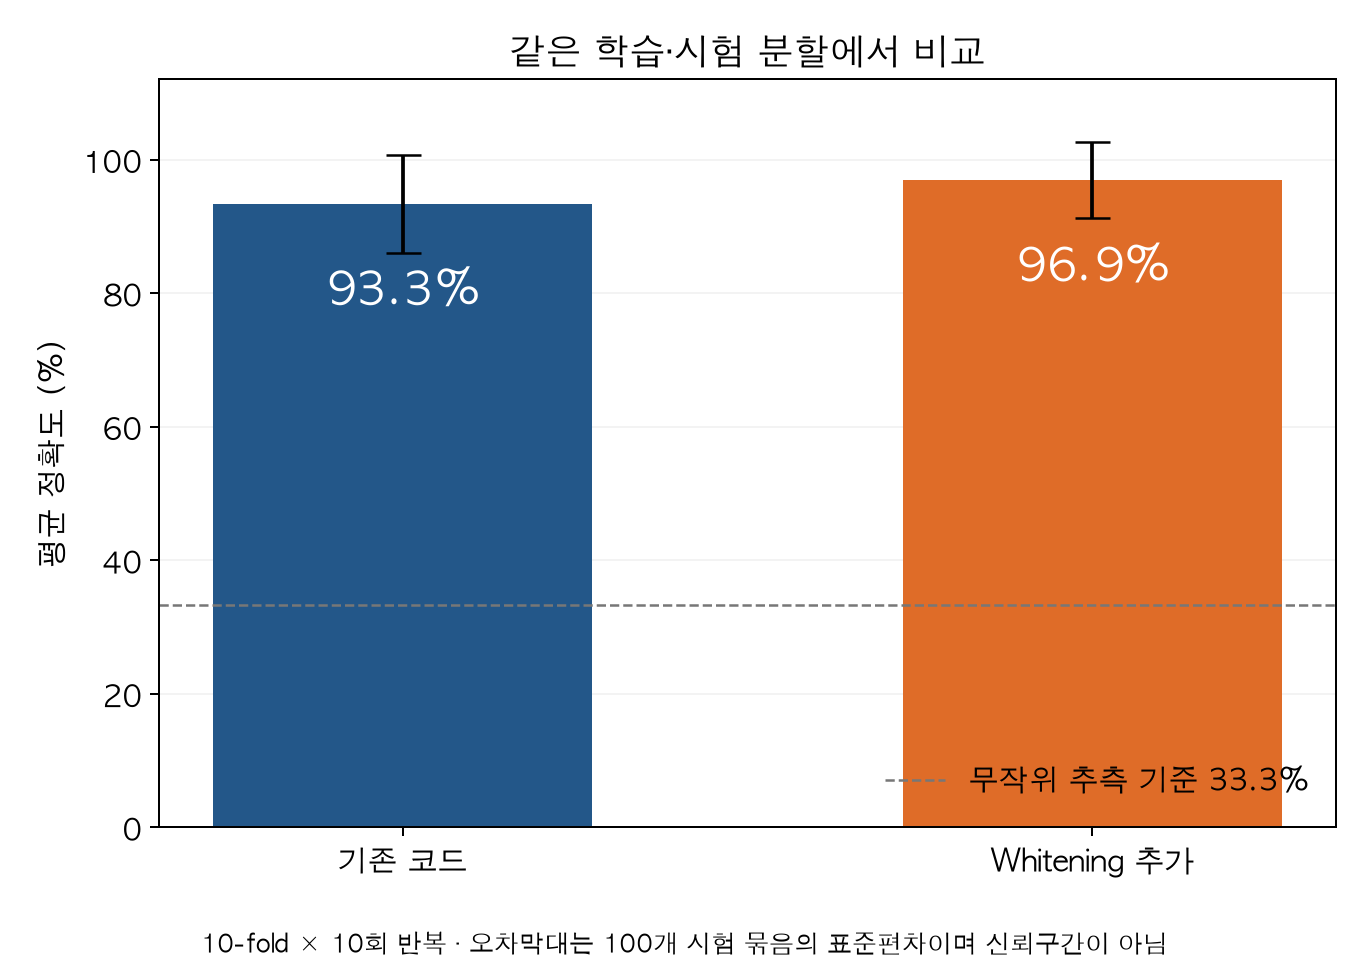

### Whitening 전후 주파수별 신호 분포

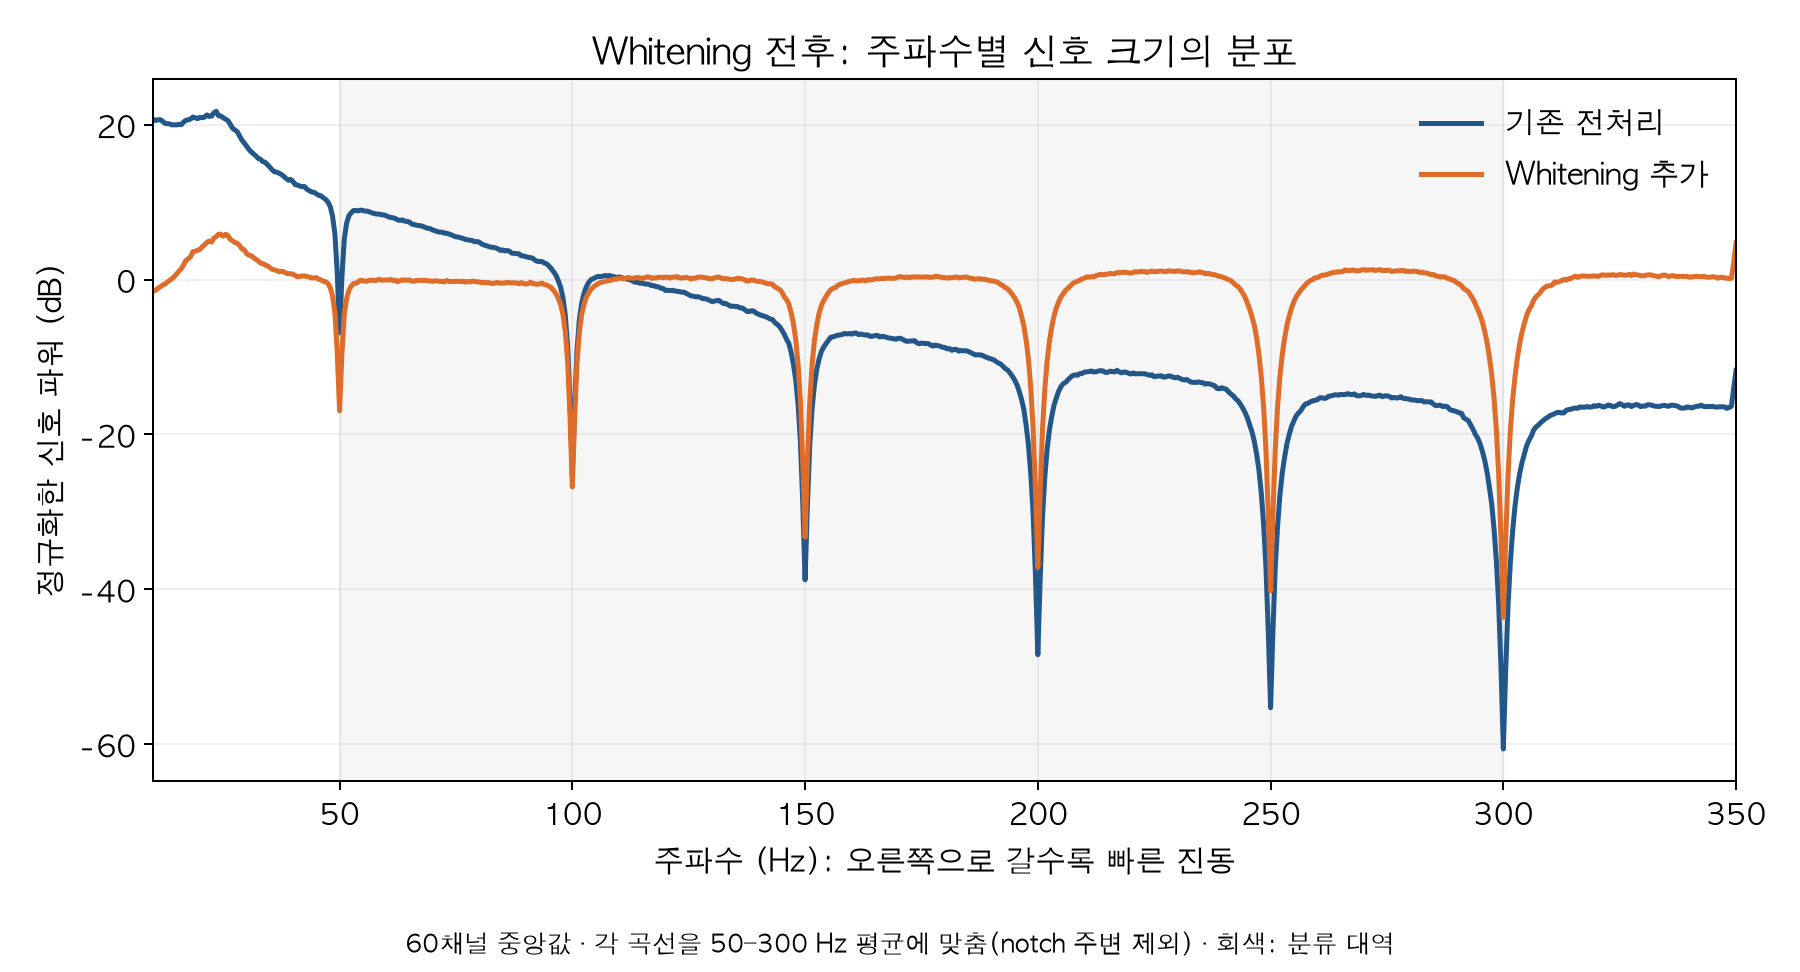

### 동작별 예측 비교

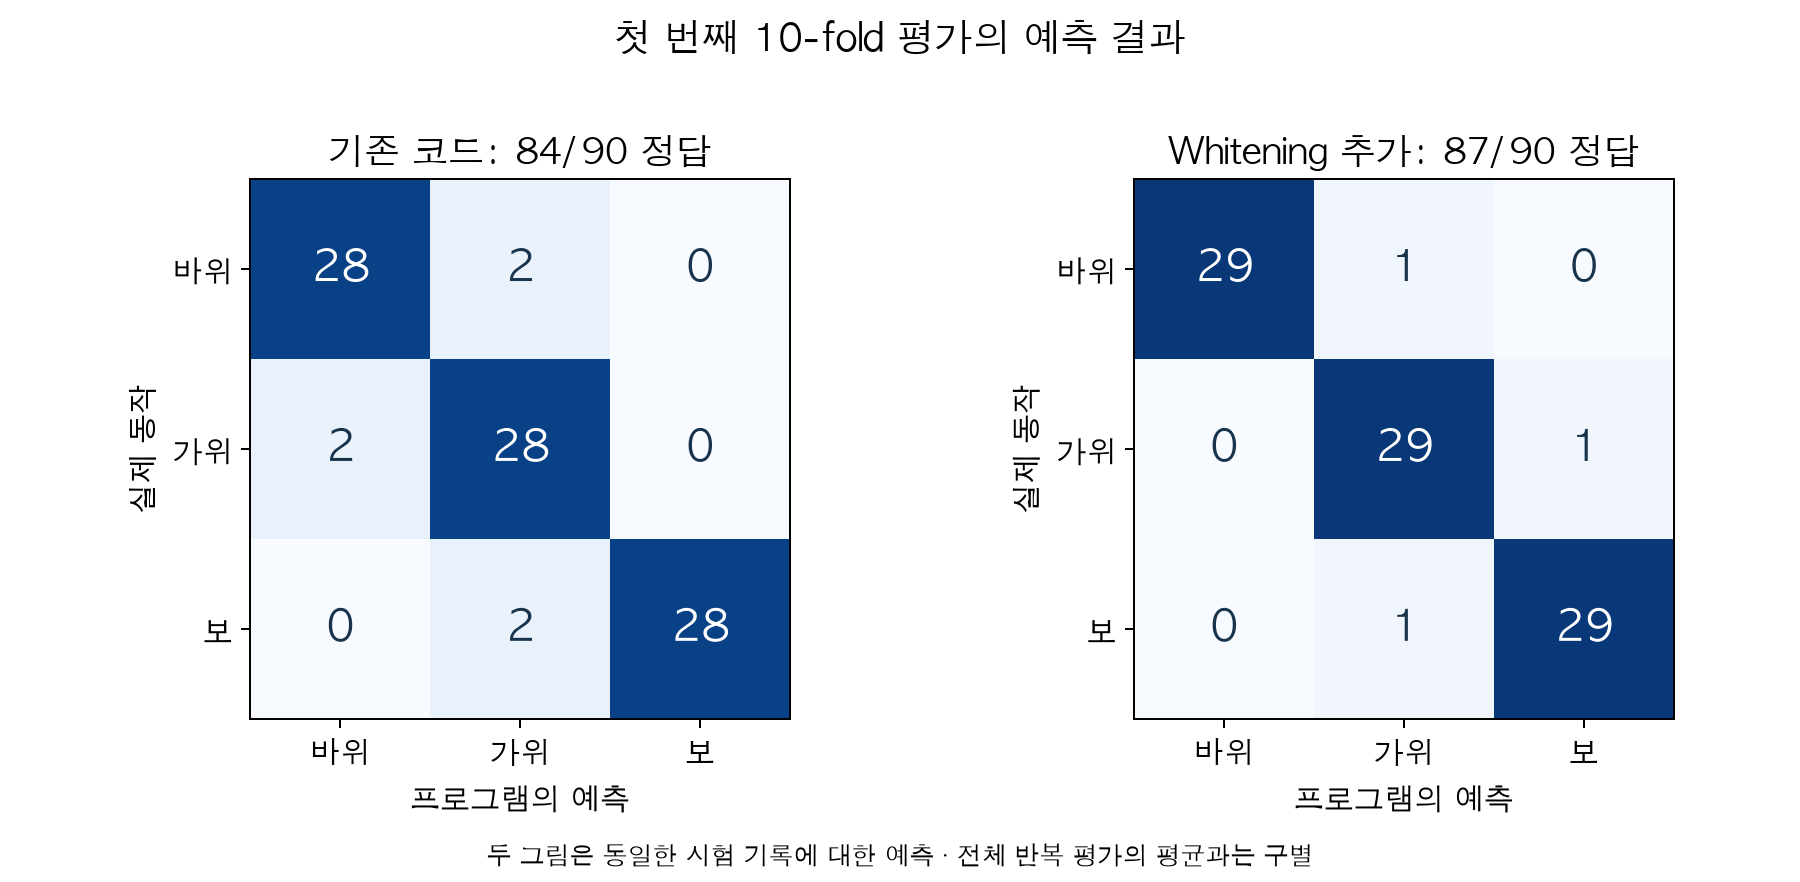

완료했습니다. 이번 실행의 수치와 그림을 results/whitening/에 저장했습니다.


In [1]:
from pathlib import Path
from contextlib import redirect_stdout
from io import StringIO
import json
import runpy
import sys
from IPython.display import Image, Markdown, display

project_directory = Path("/Users/hhlee/hackathon_project")
expected_python = Path("/Users/hhlee/miniconda3/envs/ecog/bin/python").resolve()
if Path(sys.executable).resolve() != expected_python:
    raise RuntimeError("ecog Python 환경의 커널을 선택한 뒤 다시 실행해 주세요.")

print("기존 방법과 whitening 추가 방법을 같은 조건으로 비교하고 있습니다. 약 1분 걸립니다.")
analysis_log = StringIO()
try:
    with redirect_stdout(analysis_log):
        runpy.run_path(str(project_directory / "whitening_compare.py"), run_name="__main__")
except Exception:
    print(analysis_log.getvalue())
    raise

result_directory = project_directory / "results" / "whitening"
metrics = json.loads((result_directory / "comparison_metrics.json").read_text())
table_rows = []
for test_key, test_label in [
    ("three_class", "가위·바위·보 정확도"),
    ("fist_peace", "바위·가위 정확도"),
    ("shuffled_control", "정답을 섞은 검사"),
]:
    condition_values = []
    for condition_name in ["baseline", "whitening"]:
        score = metrics[condition_name][test_key]
        condition_text = f"{score['mean_percent']:.1f}%"
        if test_key != "shuffled_control":
            condition_text += f" ± {score['std_percent']:.1f}%"
        condition_values.append(condition_text)
    table_rows.append(f"| {test_label} | {condition_values[0]} | {condition_values[1]} |")

summary = (
    "## 이번 실행에서 계산한 결과\n\n"
    "| 검사 | 기존 방법 | Whitening 추가 |\n"
    "| --- | --- | --- |\n"
    + "\n".join(table_rows)
    + f"\n\n세 동작 평균 정확도 차이: **+{metrics['paired_difference_pp']:.2f}%p**."
    + "\n\n±는 100개 시험 묶음 점수의 표준편차입니다. "
    + "아래 혼동행렬은 첫 번째 10-fold 평가만 보여줍니다."
)
display(Markdown(summary))
for image_title, image_filename in [
    ("평균 정확도 비교", "accuracy_comparison.png"),
    ("Whitening 전후 주파수별 신호 분포", "whitening_spectrum.png"),
    ("동작별 예측 비교", "confusion_comparison.png"),
]:
    display(Markdown(f"### {image_title}"))
    display(Image(filename=str(result_directory / image_filename)))

print("완료했습니다. 이번 실행의 수치와 그림을 results/whitening/에 저장했습니다.")
